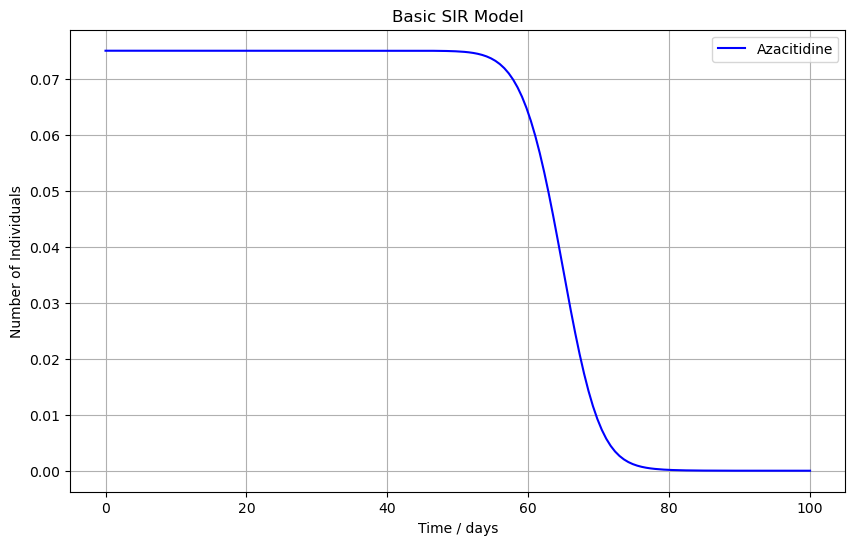

In [54]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
'''
    
    Xl1 = leukemic blasts in bone marrow
    Xl2 = leukemic blasts in the blood
    c1 and c2 = factor that modulates cytokine feedback, 0.1
    a1 = Fraction of self-renewal of leukemic cells, 0.875
    p1 = growth rate of leukemic cells, 0.1
    d2 = death rate of blasts in blood, 2.3
'''

gut = 0.075
out = 0
def Aza_Effect(y,t):
    gut,out = y
    
    dgutdt =  -gut*np.exp(-((t-30)**2)/(2*np.exp(2))) 
    doutdt = gut*np.exp(-((t-30)**2)/(2*np.exp(2)))
    #dgutdt = 0.075*np.exp(-0.023*t)
    return [dgutdt,doutdt]
    '''
        starts at zero but then after 0.5 hours it reaches its peak amount and then goes back down again until zero
        
    '''

ta = np.linspace(0,100, 160)    
ya = gut,out
ret = odeint(Aza_Effect,ya,ta)
gut,out = ret.T

    
Xl1 = 50000
Xl2=0



def blast_pop(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):#Blast population model in two compartments
     Xl1,Xl2 = y
     I = 0.075#mg dosage of azacitidine
     Eblast = I*np.exp(-0.023*t) #this is the decay of the dosage, assuming the dosage is proportional to effect on blast
     #the half life is assumed to be 41 minutes and the constant was found using ln(2)/41
     #klc = 1/(1+c1*Xwbc+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
     #dXl1dt = (a1 - Eblast)*Xl1 #change in leukemia cells in bone marrow 
     dXl1dt = Xl1*(1-gut)
     dXl2dt = 2*(1-a1)*p1*Xl1 - (d2*Xl2) #change in leukemia cells in blood
     return [dXl1dt, dXl2dt]

#t = np.linspace(0,41, 160)    
#y0 = Xl1,Xl2
#ret = odeint(blast_pop,y0,t)
#Xl1,Xl2 = ret.T
plt.figure(figsize=(10, 6))
#plt.plot(t, gut, 'b', label='Azacitidine')
#plt.plot(t, Xl2, 'r', label='Blast blood')
#plt.plot(t, Xl1, 'g', label='Blasts in marrow')
plt.title('Basic SIR Model')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()

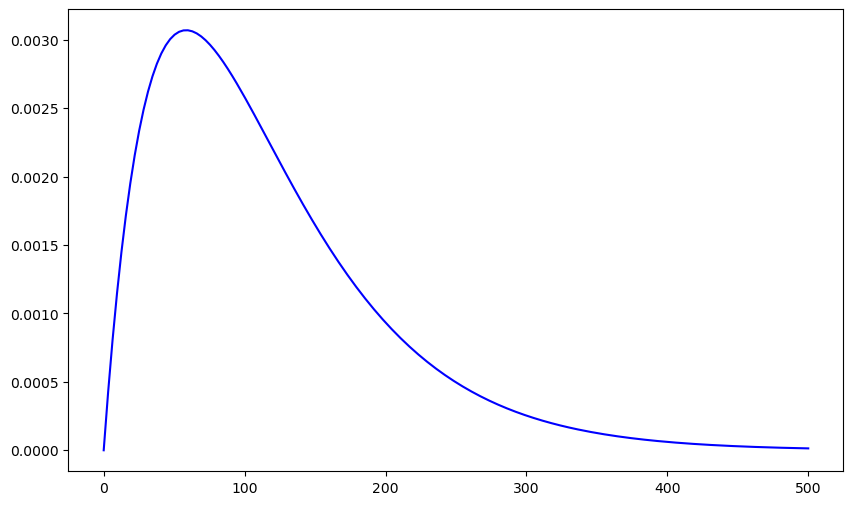

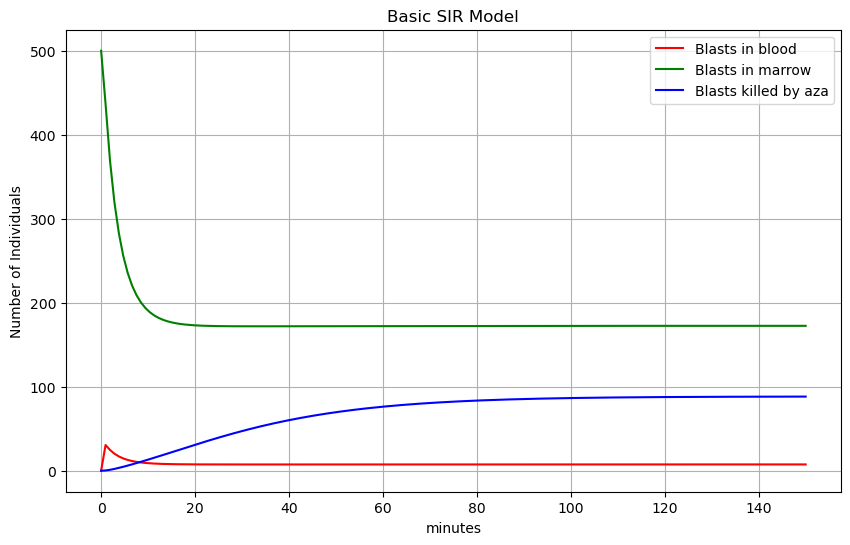

In [124]:
def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    gut,out,Xl1, Xl2,Dead = y
    '''
        F = fraction absorbed by the body, bioavailability ~11% for oral dose
        ka = the first oder absorption rate constan, 0.0173/min which was converted from 1.04/hr
        D0 = dose of the drug, 0.075
        k = rate constant of elimination  = ln(2)/halflife -> ln(2)/41mins = 0.0169
    '''
    F = 0.11
    ka = 0.0173
    D0 = 0.075
    k = 0.0169
    # rate of change in gut?  = rate of absorption - rate of elimination
    dgutdt =  F*ka*D0*np.exp(-ka*t) - k*gut
    doutdt = gut*np.exp(-((t-30)**2)/(2*np.exp(2)))
    klc = 1/(1+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
    dXl1dt = (2*a1*klc - 1 - gut)*Xl1*p1 #change in leukemia cells in bone marrow 
    dXl2dt = 2*(1-a1*klc)*p1*Xl1 - (d2*Xl2)
    dXDeaddt = gut*Xl1
    #dgutdt = 0.075*np.exp(-0.023*t)
    return [dgutdt,doutdt,dXl1dt,dXl2dt, dXDeaddt]
#function that starts at zero, goes to 1 by t= 30 and then back down to 0 as t = 60. Does so relative to its amount

Gut =0
out = 0
Xl1 =500
Xl2 = 0
Dead = 0
t = np.linspace(0,500, 160)    
y0 = Gut,out,Xl1, Xl2,Dead
ret = odeint(Aza_Effect,y0,t)
Gut,out,Xl1, Xl2,Dead = ret.T
plt.figure(figsize=(10, 6))
plt.plot(t, Gut, 'b', label='Azacitidine concentation in the plasma')
#plt.plot(t, out, 'r', label='Azacitidine')
#plt.plot(t, Xl2, 'r', label='Blast blood')
tb = np.linspace(0,150, 160)  
plt.figure(figsize=(10, 6))
plt.plot(tb, Xl2, 'r', label='Blasts in blood')
plt.plot(tb, Xl1, 'g', label='Blasts in marrow')
plt.plot(tb, Dead, 'b', label='Blasts killed by aza')
plt.title('Basic SIR Model')
plt.xlabel('minutes')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()